# Pipeline

This file details how the Movie dataset can be used. 

In [106]:
import logging

logging.basicConfig(
    level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s',
    filename='pipeline.log'
)
logger = logging.getLogger(__name__)

First load all of the data into a DuckDB database

In [107]:
import duckdb
import pandas as pd

#try-except blocks for error handling
try:
    con = duckdb.connect(database='movies.duckdb', read_only=False)
    con.execute("CREATE TABLE IF NOT EXISTS mov AS SELECT * FROM read_parquet('data/mov.parquet');")
    con.execute("CREATE TABLE IF NOT EXISTS netmov AS SELECT * FROM read_parquet('data/net_mov.parquet');")
    con.execute("CREATE TABLE IF NOT EXISTS rat AS SELECT * FROM read_parquet('data/rat.parquet');")
    con.execute("CREATE TABLE IF NOT EXISTS users AS SELECT * FROM read_parquet('data/users.parquet');")
    con.execute("CREATE TABLE IF NOT EXISTS history AS SELECT * FROM read_parquet('data/watch_history.parquet');")

    con.close()
    logger.info("Loaded data into a Duckdb database")

except Exception as e:
    print(f"An error occurred: {e}")
    logger.error(f"An error occurred: {e}")


Now moving on to querying and model building

Finding all ratings for movies that do appear on Netflix. This will be used as training data for the model. The query will return all columns from the users data table, the rating, all columns from the movie data table, and three columns from the users watch history.

In [ ]:
#SQL Query
try:
    con = duckdb.connect(database='movies.duckdb', read_only=False)
    #creating the database that the model will be trained upon
    net_df = con.execute("""
        SELECT 
            u.*, 
            r.rating, 
            m.*,
            h.num_movies_watched, h.total_minutes_watched
            FROM users u
        INNER JOIN history h ON h.userId = u.userId
        INNER JOIN rat r on r.userID = u.userId
        INNER JOIN mov m ON m.movieId = r.movieId
        LEFT JOIN netmov n ON n.movieId = m.movieId
        WHERE n.movieId IS NOT NULL;
    """).fetchdf()
    logger.info("Netflix Data extraction")
    con.close()

except Exception as e:
    print(f"An error occurred: {e}")
    logger.error(f"An error occurred: {e}")

net_df.head()

,userId,job,age,salary,rating,movieId,title,year,(no genres listed),Action,...,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western,num_movies_watched,total_minutes_watched
0,1,Truck driver,54,63088.22,5.0,111,Taxi Driver,1976,0,0,...,0,0,0,0,0,1,0,0,141,15792
1,1,Truck driver,54,63088.22,3.0,527,Schindler's List,1993,0,0,...,0,0,0,0,0,0,1,0,141,15792
2,1,Truck driver,54,63088.22,5.0,915,Sabrina,1954,0,0,...,0,0,0,1,0,0,0,0,141,15792
3,1,Truck driver,54,63088.22,3.0,971,Cat on a Hot Tin Roof,1958,0,0,...,0,0,0,0,0,0,0,0,141,15792
4,1,Truck driver,54,63088.22,1.0,1080,Monty Python's Life of Brian,1979,0,0,...,0,0,0,0,0,0,0,0,141,15792


Finding all ratings for movies that do not appear on Netflix. Limiting this to the first 500,000 reviews for memory reasons. The query will return all columns from the users data table, the rating, all columns from the movie data table, and three columns from the users watch history.

In [ ]:
#SQL Query
try:
    con = duckdb.connect(database='movies.duckdb', read_only=False)
    #creating the database that the model will be tested upon
    movs_df = con.execute("""
        SELECT 
            u.*, 
            r.rating, 
            m.*,
            h.num_movies_watched, h.total_minutes_watched
            FROM users u
        INNER JOIN history h ON h.userId = u.userId
        INNER JOIN rat r on r.userID = u.userId
        INNER JOIN mov m ON m.movieId = r.movieId
        LEFT JOIN netmov n ON n.movieId = m.movieId
        WHERE n.movieId IS NULL
        LIMIT 500000;
    """).fetchdf()
    logger.info("Non Netflix Data extraction")
    con.close()
except Exception as e:
    print(f"An error occurred: {e}")
    logger.error(f"An error occurred: {e}")

movs_df.head()

Test to ensure that there is no overlap with movies

In [111]:
#test
try:    
    df_merged = movs_df.merge(net_df, on='movieId', how='inner')
except Exception as e:
    print(f"An error occurred: {e}")
    logger.error(f"An error occurred: {e}")
df_merged.shape

(0, 59)

Now Cleaning the data to ensure it is ready for the model. 

In [76]:
movs_df.head()

,userId,job,age,salary,rating,movieId,title,year,(no genres listed),Action,...,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western,num_movies_watched,total_minutes_watched
0,773,General manager,64,89578.36,3.0,140,Up Close and Personal,1996,0,0,...,0,0,0,1,0,0,0,0,39,3627
1,773,General manager,64,89578.36,5.0,260,Star Wars: Episode IV - A New Hope,1977,0,1,...,0,0,0,0,1,0,0,0,39,3627
2,773,General manager,64,89578.36,2.0,608,Fargo,1996,0,0,...,0,0,0,0,0,1,0,0,39,3627
3,773,General manager,64,89578.36,4.0,647,Courage Under Fire,1996,0,1,...,0,0,0,0,0,0,1,0,39,3627
4,773,General manager,64,89578.36,3.0,648,Mission: Impossible,1996,0,1,...,0,0,1,0,0,1,0,0,39,3627


In [113]:
try:
    #splitting into input and prediction data
    y = movs_df["rating"]
    X = movs_df.drop("rating", axis=1)

    #getting rid of large categorical columns
    X.drop(["title", "year"], axis=1, inplace=True)

    #one hot encoding the job column
    #one hot encode
    dummies = pd.get_dummies(X["job"], prefix="job")
    #make it numerical
    dummies = dummies.astype(int)
    #join the columns
    X = X.join(dummies)
    #drop the old columns
    X.drop(columns=["job"], inplace=True)

    #finally, drop the user and movie ID columns

    X.drop(["movieId", "userId"], axis = 1, inplace=True)
    logger.info("Preparing the data for model training")

except Exception as e:
    print(f"An error occurred: {e}")
    logger.error(f"An error occurred: {e}")


In [114]:
X.head()

,age,salary,(no genres listed),Action,Adventure,Animation,Children,Comedy,Crime,Documentary,...,job_Maintenance technician,job_Marketing manager,job_Nursing assistant,job_Office clerk,job_Registered nurse,job_Retail sales associate,job_Sales manager,job_Server,job_Truck driver,job_Web developer
0,64,89578.36,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,64,89578.36,0,1,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,64,89578.36,0,0,0,0,0,1,1,0,...,0,0,0,0,0,0,0,0,0,0
3,64,89578.36,0,1,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
4,64,89578.36,0,1,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [115]:
y.head()

0    3.0
1    5.0
2    2.0
3    4.0
4    3.0
Name: rating, dtype: float64

#### Model Work

For this project, the netflix movie dataset will be split up into a training and testing dataset

In [94]:
# Importing packages
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

First the data is split up and the pipeline is built. 

In [ ]:
try:
    #further split the data to obtain a new training and testing set
    X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(X, y, test_size=0.2, random_state=42)


    #create a pipeline
    pipeline_regressor = Pipeline([
        ('regressor', RandomForestRegressor(random_state=42))
    ])
    logger.info("Building the random forest model")

except Exception as e:
    print(f"An error occurred: {e}")
    logger.error(f"An error occurred: {e}")


Then the optimal hyperparameters for this model are found using GridSearchCV. 

In [117]:
try:
    #create a parameter table
    parameter_grid_regressor = {"regressor__n_estimators": [20, 100], "regressor__max_depth": [5, 10]}
    #find best parameter
    grid_search_ridge = GridSearchCV(pipeline_regressor, parameter_grid_regressor, cv=3)
    grid_search_ridge.fit(X_train_rf, y_train_rf.values.ravel())
    print(grid_search_ridge.best_params_)
    logger.info("Finding the optimal hyperparameters")
except Exception as e:
    print(f"An error occurred: {e}")
    logger.error(f"An error occurred: {e}")


{'regressor__max_depth': 10, 'regressor__n_estimators': 100}


In [118]:
The optimal parameters are then used to train the model

SyntaxError: invalid syntax (53414179.py, line 1)

In [ ]:
try:
    #grab all the optimal parameters
    best_estimators = grid_search_ridge.best_params_["regressor__n_estimators"]
    best_depth = grid_search_ridge.best_params_["regressor__max_depth"]

    #create a new pipeline that includes the optimized parameters
    pipeline_regressor_improved = Pipeline([
        ('regressor', RandomForestRegressor(n_estimators=best_estimators, max_depth=best_depth, max_features="sqrt", random_state=42))
    ])

    #fit the pipeline again with the optimized parameters
    logger.info("Refitting the model with the ideal hyperparameters")
    pip_improved = pipeline_regressor_improved.fit(X_train_rf, y_train_rf.values.ravel())

    #make predictions
    y_pred = pipeline_regressor_improved.predict(X_test_rf)

    logger.info("Predicting using the ideal hyperparameters")
    #score
    r2 = r2_score(y_test_rf, y_pred) # Predict on the test set
    print("R2 is equal to:", r2)
    #score
    MSE = mean_squared_error(y_test_rf, y_pred)
    print("MSE is equal to: ", MSE)
    
    logger.info("Getting Metrics")

except Exception as e:
    print(f"An error occurred: {e}")
    logger.error(f"An error occurred: {e}")


In [ ]:
#visualize one of the trees
rf = pipeline_regressor_improved.named_steps["regressor"]
tree_plot = rf.estimators_[0]
cols = X_train_rf.columns

plt.figure(figsize=(20, 10))
plot_tree(tree_plot, feature_names=cols, filled=True, rounded=True, fontsize=10, max_depth = 3)
plt.title("Decision Tree from Random Forest")
plt.savefig("../outputs/tree.png")
plt.show()

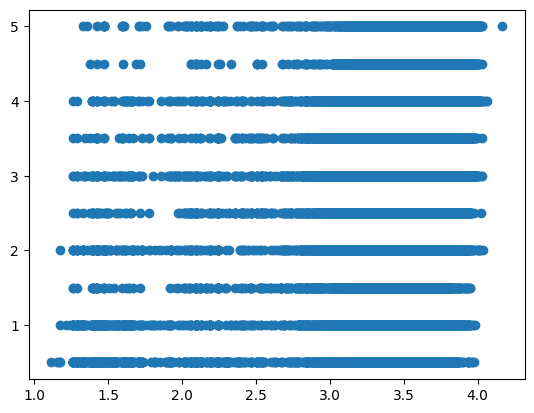

In [105]:
import matplotlib.pyplot as plt
plt.scatter(y_pred, y_test_rf)
plt.show()